# Investigating Effects of Polysome Profiling Resolution for a Translation Reporter Assay with Deep Learning

**SysBio Final Project (2025/2026)**

This notebook investigates how reducing polysome profiling resolution affects the performance of a convolutional neural network trained to predict mean ribosome load from 5′ UTR sequences.

**Reference:** Sample, P.J. et al. Human 5′ UTR design and variant effect prediction from a massively parallel translation assay. *Nature Biotechnology* 37, 803-809 (2019).

---

## Table of Contents
1. Setup and Imports
2. Data Loading
3. MRL Computation and Validation
4. Bin Merging and Resolution Schemes
5. Train/Test Split
6. One-Hot Encoding
7. Model Architecture
8. Cross-Resolution Evaluation
9. Attribution Analysis via Integrated Gradients

---
## 1. Setup and Imports <a id='1'></a>

This section initializes the computational environment, sets global random seeds for
reproducibility, and imports all required libraries.

**Google Colab note:** Installing packages mid-session (e.g. `captum`) can cause
binary incompatibilities with already-loaded packages such as `numpy`. The fix is a hard runtime restart via `os._exit(0)`, which forces a clean reload of all binaries. If this triggers, simply re-run the notebook from the top.

In [1]:
# Computational environment
import torch, platform
print(f"Python     : {platform.python_version()}")
print(f"PyTorch    : {torch.__version__}")
if torch.cuda.is_available():
    print(f"GPU        : {torch.cuda.get_device_name(0)}")
    print(f"VRAM       : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"Runtime    : ~60 min on NVIDIA A100 (Google Colab)")

Python     : 3.12.12
PyTorch    : 2.10.0+cu128
GPU        : NVIDIA A100-SXM4-40GB
VRAM       : 42.4 GB
Runtime    : ~60 min on NVIDIA A100 (Google Colab)


In [2]:
# Install Captum if missing
try:
    import captum  # noqa: F401
except Exception:
    !pip -q install captum
    import os
    os._exit(0)   # hard exit forces Colab runtime restart;
                  # needed so newly installed Captum binaries are loaded cleanly

In [3]:
# Standard library
import json
import random
from pathlib import Path

# Numerical + data handling
import numpy as np
import pandas as pd
from scipy.stats import pearsonr
from scipy.ndimage import uniform_filter1d

# Visualization
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.gridspec as gridspec

# PyTorch
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# Scikit-learn
from sklearn.model_selection import KFold, train_test_split

# Interpretability
from captum.attr import IntegratedGradients

In [4]:
# Reproducibility
SEED = 123
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# For full determinism on GPU
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Select CPU or GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [5]:
# Mount Google Drive
from google.colab import drive
drive.mount("/content/drive")

# Define project directories
DATA_DIR    = Path("/content/drive/MyDrive/polysome_project/")
FIG_OUT_DIR = DATA_DIR / "figures"
FIG_OUT_DIR.mkdir(exist_ok=True)

print("DATA_DIR:", DATA_DIR)
print("FIG_OUT_DIR:", FIG_OUT_DIR)

Mounted at /content/drive
DATA_DIR: /content/drive/MyDrive/polysome_project
FIG_OUT_DIR: /content/drive/MyDrive/polysome_project/figures


In [38]:
# Polysome bin definitions
BIN_COLS = [str(i) for i in range(14)] # original 14 bin column names
BIN_IDX  = np.arange(14, dtype=float)  # numeric bin indices (0-13)

# Schemes chosen to simulate decreasing experimental effort:
# 14 bins = full resolution (original data)
# 7/5/3 bins = paired, roughly-equal, and coarse merges of adjacent bins
MERGE_SCHEMES = {
    "14_bins": [[i] for i in range(14)],
    "7_bins":  [[0,1],[2,3],[4,5],[6,7],[8,9],[10,11],[12,13]],
    "5_bins":  [[0,1],[2,3,4],[5,6,7],[8,9,10],[11,12,13]],
    "3_bins":  [[0,1,2,3],[4,5,6,7,8],[9,10,11,12,13]],
    "2_bins":  [[0,1,2,3,4,5,6],[7,8,9,10,11,12,13]],
}

# Plotting order + colors
SCHEME_ORDER = ["14_bins", "7_bins", "5_bins", "3_bins", "2_bins"]
N_BINS_ORDER = [14, 7, 5, 3, 2]
PALETTE = {
    "14_bins": "#4C72B0",
    "7_bins":  "#DD8452",
    "5_bins":  "#55A868",
    "3_bins":  "#C44E52",
    "2_bins":  "#8172B2",
}

# Training hyperparameters (kept fixed across experiments)
N_EPOCHS   = 40 # chosen based on observed loss curve convergence; plateau begins ~epoch 40, further training risks overfitting
LR         = 1e-3
BATCH_SIZE = 256

print("Setup complete.")

Setup complete.


---
## 2. Data Loading <a id='2'></a>

We load the dataset from Sample et al. (2019)
([GSM3130435](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSM3130435)),
which contains 50-nt randomized 5′ UTR sequences paired with read counts across
14 polysome fractions.

The CSV file contains per-UTR read counts per fraction, library-size normalized
fraction abundances (r0-r13), and a pre-computed MRL estimate (rl) from the
original pipeline.

Sequences are sorted by total read count and the top 280,000 UTRs are retained.
Filtering by read depth ensures that bin count distributions are based on sufficient
sequencing coverage, yielding more reliable MRL estimates downstream.

The provided rl column is used as a sanity check in section 3 but not as the
primary MRL label. We recompute MRL directly from the bin fractions for consistency across all resolution schemes.

In [7]:
# Load full dataset for library-level normalization (required for Step 1 of MRL computation)
df_full = pd.read_csv(DATA_DIR / "GSM3130435_egfp_unmod_1.csv", index_col=0)

# Step 1: normalize raw counts within each fraction across the full library
# sum_n R_nm = total reads in fraction m across ALL UTRs (library-level)
fraction_totals  = df_full[BIN_COLS].sum(axis=0)                  # shape: (14,)
relative_r       = df_full[BIN_COLS].div(fraction_totals, axis=1) # shape: (N_full, 14)

# Step 2: normalize across fractions for each UTR
normalized_r     = relative_r.div(relative_r.sum(axis=1), axis=0) # shape: (N_full, 14)

# Store normalized fractions back into df_full as 'rn0'..'rn13'
# (named differently from the provided r0..r13 to avoid confusion)
for i in range(14):
    df_full[f"rn{i}"] = normalized_r[str(i)].values

# Sort by read depth and keep top 280k sequences
df_full.sort_values("total_reads", inplace=True, ascending=False)
df_full.reset_index(inplace=True, drop=True)
df = df_full.iloc[:280000].copy()

# Columns used for MRL computation: raw bin counts '0'-'13'
# r0-r13: provided normalized fractions from original pipeline (not used directly)
# rn0-rn13: our recomputed normalized fractions via two-step normalization
# rl: (presumely) pre-computed MRL from Sample et al. (used as sanity check only)

---
## 3. MRL Computation and Validation <a id='3'></a>

Mean Ribosome Load (MRL) quantifies the average number of ribosomes bound to an
mRNA. We follow the normalization pipeline from Sample et al. (2019)
(Supplementary Note 1), which involves two steps:

**Step 1:** Normalize reads within each fraction across the full library
(Relative-R$_{nm}$), to account for differences in total read counts between fractions:

$$
\text{Relative-}R_{nm} = \frac{R_{nm}}{\sum_n R_{nm}}
$$

**Step 2:** Normalize across fractions for each UTR (Normalized-R$_{nm}$),
to account for differences in total read counts between UTRs:

$$
\text{Normalized-}R_{nm} = \frac{\text{Relative-}R_{nm}}{\sum_m \text{Relative-}R_{nm}}
$$

MRL is then the weighted sum of normalized abundances, with bin index $m$ (0-13)
as the weight:

$$
\text{MRL}_n = \sum_{m} \left( \text{Normalized-}R_{nm} \times m \right)
$$

Step 1 requires the complete library. Normalization within each fraction must
be computed across all UTRs. We therefore load the full dataset first, apply both normalization steps, and then filter to the top 280k sequences by read depth.

For low-resolution schemes, adjacent raw count columns are pooled before
applying the same two-step normalization, correctly simulating what would be
measured if fewer fractions were physically collected.

**Validation:** Our recomputed MRL is compared against the provided `rl` column
from the original pipeline. Close to zero MAE and PCC ≈ 1.000 though confirm correct implementation.

In [8]:
def compute_highres_mrl(df_subset):
    """Compute MRL using recomputed normalized fractions ('rn0'..'rn13').
    These are computed from raw counts via the full two-step normalization
    from Sample et al. (2019) Supplementary Note 1.
    """
    R_COLS = [f"rn{i}" for i in range(14)]  # our recomputed normalized fractions
    w = df_subset[R_COLS].values             # shape: (N, 14)
    return (w * BIN_IDX).sum(axis=1)         # weighted sum = MRL

# Compute low-resolution MRL for a given merge scheme
def compute_lowres_mrl(df_subset, scheme):
    """Merge adjacent bins and compute weighted MRL using group midpoints.

    Uses raw count columns ("0".."13") rather than pre-normalized r{i} columns,
    because summing raw counts before renormalizing correctly simulates pooling
    physical fractions in a lower-resolution experiment; i.e. what you would
    actually measure if you only collected len(scheme) tubes.
    """
    w = df_subset[BIN_COLS].div(df_subset[BIN_COLS].sum(axis=1), axis=0)  # normalize each row to sum to 1
    merged = np.stack(
      [w[[str(i) for i in group]].sum(axis=1).values for group in scheme],
      axis=1,
    )  # sum normalized fractions within each bin group -> shape (N, n_merged_bins)
    midpoints = np.array([np.mean(group) for group in scheme])  # representative bin index per group
    return (merged * midpoints).sum(axis=1)  # weighted sum = MRL

# Validate high-res MRL against provided rl column
df["mrl_from_bins"] = compute_highres_mrl(df)

mae = float(np.mean(np.abs(df["mrl_from_bins"].values - df["rl"].values)))
print("MRL recomputation vs provided 'rl' column")
print(f"  MAE:  {mae:.4f}")
print()
print("  mrl_from_bins distribution:")
desc = df["mrl_from_bins"].describe()
for stat, val in desc.items():
    print(f"    {stat:<8} {val:.4f}")

MRL recomputation vs provided 'rl' column
  MAE:  0.1252

  mrl_from_bins distribution:
    count    280000.0000
    mean     6.5995
    std      1.6636
    min      0.0000
    25%      5.1978
    50%      7.2729
    75%      7.9717
    max      12.0000


In [9]:
# MAE is non-zero probably due to normalization differences in the original pipeline;
# PCC confirms the computation is consistent.
pcc_vs_rl = float(pearsonr(df["mrl_from_bins"].values, df["rl"].values)[0])
print(f"  PCC:  {pcc_vs_rl:.6f}  (expected >0.999)")
assert pcc_vs_rl > 0.999, "MRL computation is inconsistent with provided rl column!"
print("MRL validation passed.")

  PCC:  0.999911  (expected >0.999)
MRL validation passed.


In [10]:
# MAE of ~0.125 persists despite implementing the exact two-step normalization
# from Sample et al. This indicates a difference in upstream processing
# that is not reproducible from the published CSV alone. PCC >0.9999 confirms
# rankings are identical and this does not affect downstream analyses.

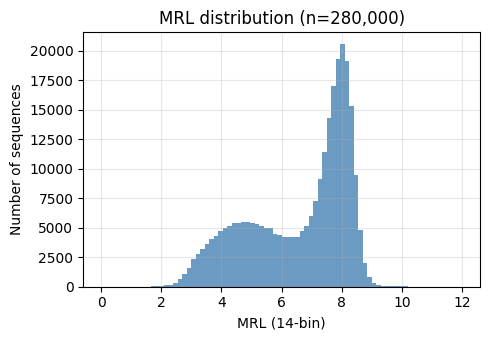

In [11]:
fig, ax = plt.subplots(figsize=(5, 3.5))
ax.hist(df["mrl_from_bins"], bins=80, color="steelblue", edgecolor="none", alpha=0.8)
ax.set_xlabel("MRL (14-bin)")
ax.set_ylabel("Number of sequences")
ax.set_title("MRL distribution (n=280,000)")
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(FIG_OUT_DIR / "mrl_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

---
## 4. Bin Merging and Resolution Schemes <a id='4'></a>

To simulate lower-resolution polysome profiling experiments, adjacent bins are merged and MRL is recomputed using the midpoint of each merged group as its effective ribosome count.

We quantify the information loss introduced by each scheme using mean absolute error (MAE) and Pearson correlation (PCC) relative to the high-resolution (14-bin) reference.

In [12]:
# Compute and store MRL for each resolution scheme
mrl_per_scheme = {
    name: compute_lowres_mrl(df, scheme)
    for name, scheme in MERGE_SCHEMES.items()
}

In [14]:
# Compare low-resolution MRLs to high-resolution reference
mrl_high = df["mrl_from_bins"].values

rows = []
for name in MERGE_SCHEMES:
    low = mrl_per_scheme[name]
    rows.append({
        "scheme":      name,
        "n_bins":      len(MERGE_SCHEMES[name]),
        "MAE_vs_high": float(np.mean(np.abs(low - mrl_high))),
        "PCC_vs_high": float(pearsonr(low, mrl_high)[0]),
    })
info_df = pd.DataFrame(rows).sort_values("n_bins", ascending=False)
# Summary table across resolution levels
print("Resolution comparison: low-res MRL vs 14-bin reference")
print("  (MAE and PCC computed across all genes, no model involved)")
print()
print(info_df.to_string(index=False))

Resolution comparison: low-res MRL vs 14-bin reference
  (MAE and PCC computed across all genes, no model involved)

 scheme  n_bins  MAE_vs_high  PCC_vs_high
14_bins      14 4.544390e-14     1.000000
 7_bins       7 2.359615e-02     0.999826
 5_bins       5 5.527351e-02     0.999546
 3_bins       3 1.355228e-01     0.997983
 2_bins       2 3.400724e-01     0.980459


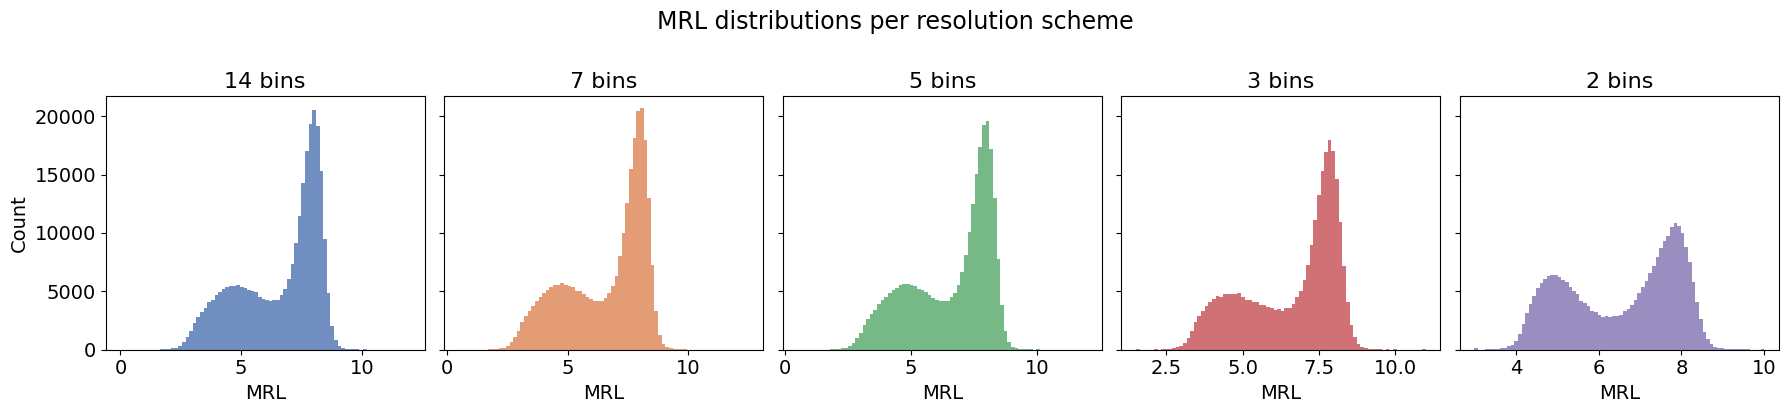

In [20]:
fig, axes = plt.subplots(1, 5, figsize=(18, 4), sharey=True)

FONT = 14

for ax, scheme_name in zip(axes, SCHEME_ORDER):  # assumes SCHEME_ORDER = 14,7,5,3,2
    ax.hist(mrl_per_scheme[scheme_name], bins=80,
            color=PALETTE[scheme_name], edgecolor="none", alpha=0.8)
    ax.set_title(scheme_name.replace("_", " "), fontsize=FONT + 2)
    ax.set_xlabel("MRL", fontsize=FONT)
    ax.tick_params(labelsize=FONT)

axes[0].set_ylabel("Count", fontsize=FONT)
fig.suptitle("MRL distributions per resolution scheme", fontsize=FONT + 3, y=1.02)
fig.tight_layout()
fig.savefig(FIG_OUT_DIR / "mrl_distributions_per_scheme.png", dpi=300, bbox_inches="tight")
plt.show()

In [21]:
# Key takeaway: MRL labels are robust to bin merging down to 3 bins; PCC vs
# 14-bin reference stays above 0.997 (MAE < 0.14). At 2 bins the label quality
# drops more sharply (PCC = 0.980, MAE = 0.34). CNN performance is similarly
# flat across 14→3bins (ΔPCC < 0.001), but attribution profiles diverge at low resolution.

---
## 5. Train / Test Split <a id='5'></a>

The dataset is partitioned into fixed training (70%), validation (10%), and held-out test (20%) sets.

| Split | Fraction | N | Purpose |
|-------|----------|---|---------|
| Train | 70% | 196,000 | Model training during architecture search |
| Val | 10% | 28,000 | Architecture selection only (early stopping signal and config ranking during architecture search) |
| Test | 20% | 56,000 | Final evaluation (never seen during training or model selection) |

After architecture selection, train and val are combined (224,000 sequences) and used as the cross-validation pool for the resolution sweep and for the final retrain.


Row indices are randomly sampled using a fixed seed and saved to disk to ensure that all subsequent experiments (architecture search, resolution sweeps, attribution analysis) use the identical data partition.

In [22]:
# Create train / val / test split (80 / 10 / 20 total -> 80% trainval, then 10% val from that)
all_idx = np.arange(len(df)) # integer indices for all 280k rows

trainval_idx, test_idx = train_test_split(
    all_idx, test_size=0.20, random_state=SEED, shuffle=True
) # hold out 20% as test set

train_idx, val_idx = train_test_split(
    trainval_idx, test_size=0.125, random_state=SEED, shuffle=True
) # 12.5% of remaining 80% = 10% of total -> final: 70/10/20

print("Dataset split (70 / 10 / 20)")
print(f"  Train : {len(train_idx):>7,}  ({len(train_idx)/len(df)*100:.1f}%)")
print(f"  Val   : {len(val_idx):>7,}  ({len(val_idx)/len(df)*100:.1f}%)")
print(f"  Test  : {len(test_idx):>7,}  ({len(test_idx)/len(df)*100:.1f}%)")
print(f"  Total : {len(df):>7,}  (indices saved to {DATA_DIR})")
print()
assert len(train_idx) + len(val_idx) + len(test_idx) == len(df) # sanity check: no rows lost

# Save indices to disk so all experiments use the identical partition
np.save(DATA_DIR / "train_idx.npy", train_idx)
np.save(DATA_DIR / "val_idx.npy",   val_idx)
np.save(DATA_DIR / "test_idx.npy",  test_idx)
print("Indices saved.")

# dataframe subsets
df_train = df.iloc[train_idx].reset_index(drop=True)
df_val   = df.iloc[val_idx].reset_index(drop=True)
df_test  = df.iloc[test_idx].reset_index(drop=True)

# Verify MRL distribution is consistent across splits (no accidental stratification bias)
print("MRL distribution per split (expect ~equal mean/std across splits):")
print(f"  {'split':<6}  {'mean':>7}  {'std':>7}")
for name, subset in [("Train", df_train), ("Val", df_val), ("Test", df_test)]:
    m, s = subset["mrl_from_bins"].mean(), subset["mrl_from_bins"].std()
    print(f"  {name:<6}  {m:>7.4f}  {s:>7.4f}")

Dataset split (70 / 10 / 20)
  Train : 196,000  (70.0%)
  Val   :  28,000  (10.0%)
  Test  :  56,000  (20.0%)
  Total : 280,000  (indices saved to /content/drive/MyDrive/polysome_project)

Indices saved.
MRL distribution per split (expect ~equal mean/std across splits):
  split      mean      std
  Train    6.6022   1.6616
  Val      6.5998   1.6673
  Test     6.5900   1.6687


---
## 6. One-Hot Encoding <a id='6'></a>

Before being passed to the CNN, each 50-nt 5′ UTR sequence is converted into a
numerical tensor using **one-hot encoding**. Each nucleotide is represented as a
length-4 binary vector over the alphabet {A, C, G, T/U}, resulting in a (4 x 50)
matrix per sequence:
```
A   -> [1, 0, 0, 0]
C   -> [0, 1, 0, 0]
G   -> [0, 0, 1, 0]
T/U -> [0, 0, 0, 1]
```

All three data splits are encoded once and kept in memory to avoid repeated
preprocessing during training. Regression targets (MRL values) are stored as
float32 tensors alongside the encoded sequences.

Final tensor shape: `(n_sequences, 4, 50)`, matching the channels-first input
format expected by `nn.Conv1d(in_channels=4, ...)`.

In [23]:
# Nucleotide -> channel index mapping (A,C,G,T; U treated as T)
_NUC_TO_IDX = {'A': 0, 'C': 1, 'G': 2, 'T': 3, 'U': 3}

def one_hot(seqs: list) -> torch.Tensor:
    """Convert a list of nucleotide strings to a one-hot tensor of shape (N, 4, L)."""
    N, L = len(seqs), len(seqs[0])                # number of sequences, sequence length
    out  = torch.zeros((N, 4, L), dtype=torch.float32)  # initialize empty tensor
    for i, seq in enumerate(seqs):
        for j, nuc in enumerate(seq.upper()):     # .upper() handles lowercase input
            out[i, _NUC_TO_IDX[nuc], j] = 1.0     # set the correct channel to 1
    return out  # shape: (N, 4, L) - channels-first format expected by nn.Conv1d

print("Encoding sequences …")
X_train = one_hot(list(df_train["utr"]))
X_val   = one_hot(list(df_val["utr"]))
X_test  = one_hot(list(df_test["utr"]))

print(f"X_train: {tuple(X_train.shape)}  X_val: {tuple(X_val.shape)}  X_test: {tuple(X_test.shape)}")

# Sanity check: each position should have exactly one active nucleotide (columns sum to 1)
assert torch.allclose(X_train.sum(dim=1), torch.ones(len(X_train), 50)), \
    "One-hot columns don't sum to 1!"
print("✓ One-hot encoding validated.")

# Regression targets: high-resolution 14-bin MRL for each split
y_train = torch.tensor(df_train["mrl_from_bins"].values, dtype=torch.float32)
y_val   = torch.tensor(df_val["mrl_from_bins"].values,   dtype=torch.float32)
y_test  = torch.tensor(df_test["mrl_from_bins"].values,  dtype=torch.float32)

Encoding sequences …
X_train: (196000, 4, 50)  X_val: (28000, 4, 50)  X_test: (56000, 4, 50)
✓ One-hot encoding validated.


---
## 7. Model Architecture and Architecture Search <a id='7'></a>

We use a 1D convolutional neural network (CNN) to predict MRL from one-hot encoded 5′ UTR sequences, following the architecture class used in Sample et al. (2019).
The model consists of three convolutional layers (Conv1d + ReLU) that extract local sequence motifs, followed by a flattening step and a fully connected (FC) regression head that maps the learned features to a scalar MRL prediction:
```
Input (N, 4, 50)
→ 3 x [Conv1d + ReLU]     # local motif extraction
→ Flatten                  # (N, n_filters x 50)
→ n_fc_layers x [Linear + ReLU + Dropout]
→ Linear(1)                # scalar MRL prediction
```

To select a well-performing architecture without exhaustive search, we evaluate
a fixed set of 15 configurations covering the following hyperparameters:

- `kernel_size` (5, 9, 13) - controls the width of detected sequence motifs
- `n_filters` (64, 120, 256) - controls convolutional feature map capacity
- `n_fc_layers` (1, 2) - depth of the regression head
- `fc_width` (20, 40, 80) - number of neurons per FC layer
- `dropout` (0.1, 0.2, 0.3) - regularization strength

Each configuration is trained on the training set (196,000 sequences) using
14-bin high-resolution MRL labels. After every epoch, validation PCC is computed
on the validation set (28,000 sequences) and used for two purposes: early stopping (training halts if val PCC does not improve for 5 consecutive epochs, and the best model weights are restored) and config ranking (the best val PCC achieved across all epochs is recorded). After all 15 configs are evaluated, the configuration with the highest val PCC is selected and fixed for all subsequent experiments.

The selected architecture is retrained on the combined train+val set (224,000
sequences) for 40 epochs without early stopping before final evaluation.

In [24]:
class CNNModel(nn.Module):
    """
    1D CNN to predict MRL from one-hot 5'UTR input (N, 4, L).
    3x(Conv1d + ReLU) -> Flatten -> n_fc_layersx(Linear + ReLU + Dropout) -> Linear(1)
    """
    def __init__(self, seq_len=50, n_filters=120, kernel_size=8,
                 fc_width=40, n_fc_layers=1, dropout=0.2):
        super().__init__()

        # 3-layer conv stack; extracts local sequence motifs at each position
        self.convs = nn.Sequential(
            nn.Conv1d(4,         n_filters, kernel_size, padding="same"), nn.ReLU(),
            nn.Conv1d(n_filters, n_filters, kernel_size, padding="same"), nn.ReLU(),
            nn.Conv1d(n_filters, n_filters, kernel_size, padding="same"), nn.ReLU(),
        )

        # Flatten conv output (n_filters x seq_len) into a vector
        in_dim = n_filters * seq_len

        # MLP head (depth controlled by n_fc_layers)
        fc_layers = []
        for _ in range(n_fc_layers):
            fc_layers += [nn.Linear(in_dim, fc_width), nn.ReLU(), nn.Dropout(dropout)]
            in_dim = fc_width # output of this layer becomes input of the next

        # Final regression output
        fc_layers.append(nn.Linear(in_dim, 1)) # single scalar output = predicted MRL
        self.fc = nn.Sequential(*fc_layers)

    def forward(self, x):
        x = self.convs(x)   # (N, n_filters, L) - local motif features
        x = x.flatten(1)    # (N, n_filters*L)  - collapse spatial dim
        return self.fc(x)   # (N, 1)            - MRL prediction

In [25]:
def train_one_epoch(model, loader, optimizer, criterion):
    """Train the model for one epoch, returning the average epoch loss."""
    model.train()  # enable dropout
    total = 0.0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()          # clear gradients from previous batch
        preds = model(xb)              # forward pass
        loss  = criterion(preds, yb)   # MSE loss
        loss.backward()                # backpropagate
        optimizer.step()               # update weights
        total += loss.item()
    return total / len(loader)         # mean loss across batches

@torch.no_grad()
def evaluate_pcc(model, loader):
    """Evaluate the model on the given loader and return the PCC."""
    model.eval()  # disable dropout for evaluation
    preds, targets = [], []
    for xb, yb in loader:
        preds.append(model(xb.to(device)).cpu().squeeze())
        targets.append(yb.squeeze())
    p = torch.cat(preds).numpy()
    t = torch.cat(targets).numpy()
    # Guard: pearsonr is undefined if predictions collapse to a constant
    if np.std(p) < 1e-8 or np.std(t) < 1e-8:
        return float("nan")
    return float(pearsonr(p, t)[0])

def train_model(config, X_tr, y_tr, X_v=None, y_v=None,
                n_epochs=N_EPOCHS, verbose=False,
                patience=5, record_loss=False):
    """
    Initialize CNN with given config, train on training set,
    and optionally validate on a held-out validation set.

    If X_v / y_v are provided:
      - val PCC is tracked each epoch
      - early stopping is applied: training halts if val PCC does not
        improve by at least 1e-4 for `patience` consecutive epochs
      - the best model weights (highest val PCC) are restored before returning

    If no validation set is provided (final retraining on train+val combined):
      - trains for the full n_epochs without early stopping
      - returns None as val_pcc (no held-out set to evaluate against)

    If record_loss=True, per-epoch train losses are recorded and returned.
    Otherwise train_losses is returned as an empty list.

    Returns: (val_pcc or None, trained model, train_losses)
    """
    model     = CNNModel(**config).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    criterion = nn.MSELoss()

    # Wrap training data in a DataLoader for batched iteration
    train_dl = DataLoader(
        TensorDataset(X_tr, y_tr.unsqueeze(1)),
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=0,
    )

    # Only build a val loader if a validation set was actually passed in
    val_dl = None
    if X_v is not None and y_v is not None:
        val_dl = DataLoader(
            TensorDataset(X_v, y_v.unsqueeze(1)),
            batch_size=BATCH_SIZE,
            shuffle=False,
            num_workers=0,
        )

    # Early-stopping state (only used when val_dl exists)
    best_val_pcc     = -np.inf  # best validation PCC seen so far
    best_state       = None     # model weights at that best epoch
    patience_counter = 0        # epochs without meaningful improvement

    train_losses = []           # populated only when record_loss=True

    for epoch in range(n_epochs):
        # One full pass through training data; returns mean batch loss
        loss = train_one_epoch(model, train_dl, optimizer, criterion)

        if record_loss:
            train_losses.append(loss)  # store epoch loss for later plotting

        if val_dl is not None:
            # Evaluate on held-out val set after every epoch
            current_val_pcc = evaluate_pcc(model, val_dl)
            if verbose:
                print(f"  epoch {epoch+1}/{n_epochs}  "
                      f"train_loss={loss:.4f}  val_pcc={current_val_pcc:.4f}")

            if current_val_pcc > best_val_pcc + 1e-4:  # meaningful improvement threshold
                best_val_pcc     = current_val_pcc
                best_state       = {k: v.clone() for k, v in model.state_dict().items()}  # snapshot weights
                patience_counter = 0        # reset patience on improvement
            else:
                patience_counter += 1       # no improvement this epoch
                if patience_counter >= patience:
                    if verbose:
                        print(f"  Early stopping at epoch {epoch+1} "
                              f"(no improvement for {patience} epochs)")
                    break
        else:
            if verbose:
                print(f"  epoch {epoch+1}/{n_epochs}  train_loss={loss:.4f}")

    # Restore weights from best epoch (only relevant when early stopping was active)
    if best_state is not None:
        model.load_state_dict(best_state)

    val_pcc = best_val_pcc if val_dl is not None else None
    return val_pcc, model, train_losses

In [26]:
# Architecture search is performed on 14-bin high-res MRL only.
# A single fixed architecture is then reused for all resolution experiments,
# ensuring that performance differences across resolutions are not confounded
# by architectural variation.

# We vary conv capacity (kernel_size, n_filters) and MLP head (n_fc_layers, fc_width, dropout)
FIXED_CONFIGS = [
    # Baseline reference
    {"kernel_size": 9,  "n_filters": 120, "n_fc_layers": 1, "fc_width": 40, "dropout": 0.2},
    # Kernel size sweep
    {"kernel_size": 5,  "n_filters": 120, "n_fc_layers": 1, "fc_width": 40, "dropout": 0.2},
    {"kernel_size": 13, "n_filters": 120, "n_fc_layers": 1, "fc_width": 40, "dropout": 0.2},
    # Filter sweep (model capacity)
    {"kernel_size": 9,  "n_filters": 64,  "n_fc_layers": 1, "fc_width": 40, "dropout": 0.2},
    {"kernel_size": 9,  "n_filters": 256, "n_fc_layers": 1, "fc_width": 40, "dropout": 0.2},
    # Dropout sweep
    {"kernel_size": 9,  "n_filters": 120, "n_fc_layers": 1, "fc_width": 40, "dropout": 0.1},
    {"kernel_size": 9,  "n_filters": 120, "n_fc_layers": 1, "fc_width": 40, "dropout": 0.3},
    # FC width sweep
    {"kernel_size": 9,  "n_filters": 120, "n_fc_layers": 1, "fc_width": 20, "dropout": 0.2},
    {"kernel_size": 9,  "n_filters": 120, "n_fc_layers": 1, "fc_width": 80, "dropout": 0.2},
    # Deeper FC head
    {"kernel_size": 9,  "n_filters": 120, "n_fc_layers": 2, "fc_width": 40, "dropout": 0.2},
    {"kernel_size": 9,  "n_filters": 120, "n_fc_layers": 2, "fc_width": 80, "dropout": 0.2},
    {"kernel_size": 9,  "n_filters": 120, "n_fc_layers": 2, "fc_width": 40, "dropout": 0.3},
    # Cross-combinations
    {"kernel_size": 5,  "n_filters": 256, "n_fc_layers": 1, "fc_width": 40, "dropout": 0.3},
    {"kernel_size": 13, "n_filters": 64,  "n_fc_layers": 2, "fc_width": 40, "dropout": 0.1},
    {"kernel_size": 13, "n_filters": 256, "n_fc_layers": 2, "fc_width": 80, "dropout": 0.3},
]
print(f"Fixed architecture configs to evaluate: {len(FIXED_CONFIGS)}")

search_results = []
for i, config in enumerate(FIXED_CONFIGS):
  # Cast to correct types (guards against float kernel_size from CSV reload)
    config = {
        "kernel_size":  int(config["kernel_size"]),
        "n_filters":    int(config["n_filters"]),
        "n_fc_layers":  int(config["n_fc_layers"]),
        "fc_width":     int(config["fc_width"]),
        "dropout":      float(config["dropout"]),
    }

    # Retry loop: rare weight initialization can cause the model to collapse
    # (constant predictions, val_pcc ≈ 0 or NaN). Retry with a shifted seed.
    MAX_RETRIES = 3
    for attempt in range(MAX_RETRIES):
        # Seed derived from config index + attempt -> deterministic but independent
        torch.manual_seed(SEED + i * 10 + attempt) # deterministic but independent per attempt
        np.random.seed(SEED + i * 10 + attempt)
        val_pcc, _, _ = train_model(config, X_train, y_train, X_val, y_val)
        # Any model on this dataset should reach >>0.1 PCC;
        # anything below indicates a collapsed / failed run
        if val_pcc is not None and not np.isnan(val_pcc) and val_pcc > 0.1:
            break # successful run
        print(f"↻ config {i+1} collapsed "
              f"(attempt {attempt+1}/{MAX_RETRIES}), retrying…")
    # Restore global seed so retries don't affect subsequent configs
    torch.manual_seed(SEED)
    np.random.seed(SEED)

    search_results.append({**config, "val_pcc": val_pcc})
    print(f"  [{i+1}/{len(FIXED_CONFIGS)}]  {config}  val_pcc={val_pcc:.4f}")

# Rank configs by validation performance and save for reproducibility
results_df = pd.DataFrame(search_results).sort_values("val_pcc", ascending=False)
results_df.to_csv(DATA_DIR / "arch_search_results.csv", index=False)
print("\nTop 5:\n", results_df.head().to_string(index=False))

# Extract best config (excluding the metric column) for downstream retraining/eval
all_keys = [c for c in results_df.columns if c != "val_pcc"]
best_config = {
    k: (int(results_df.iloc[0][k]) if k != "dropout" else float(results_df.iloc[0][k]))
    for k in all_keys
}
print("\nBest config:", best_config)

Fixed architecture configs to evaluate: 15
  [1/15]  {'kernel_size': 9, 'n_filters': 120, 'n_fc_layers': 1, 'fc_width': 40, 'dropout': 0.2}  val_pcc=0.9389
  [2/15]  {'kernel_size': 5, 'n_filters': 120, 'n_fc_layers': 1, 'fc_width': 40, 'dropout': 0.2}  val_pcc=0.9358
  [3/15]  {'kernel_size': 13, 'n_filters': 120, 'n_fc_layers': 1, 'fc_width': 40, 'dropout': 0.2}  val_pcc=0.9299
  [4/15]  {'kernel_size': 9, 'n_filters': 64, 'n_fc_layers': 1, 'fc_width': 40, 'dropout': 0.2}  val_pcc=0.9384
  [5/15]  {'kernel_size': 9, 'n_filters': 256, 'n_fc_layers': 1, 'fc_width': 40, 'dropout': 0.2}  val_pcc=0.9373
  [6/15]  {'kernel_size': 9, 'n_filters': 120, 'n_fc_layers': 1, 'fc_width': 40, 'dropout': 0.1}  val_pcc=0.9426
  [7/15]  {'kernel_size': 9, 'n_filters': 120, 'n_fc_layers': 1, 'fc_width': 40, 'dropout': 0.3}  val_pcc=0.9279
  [8/15]  {'kernel_size': 9, 'n_filters': 120, 'n_fc_layers': 1, 'fc_width': 20, 'dropout': 0.2}  val_pcc=0.9126
  [9/15]  {'kernel_size': 9, 'n_filters': 120, 'n_fc_

  epoch 1/40  train_loss=3.3951
  epoch 2/40  train_loss=1.6883
  epoch 3/40  train_loss=1.0084
  epoch 4/40  train_loss=0.8887
  epoch 5/40  train_loss=0.7814
  epoch 6/40  train_loss=0.6650
  epoch 7/40  train_loss=0.5961
  epoch 8/40  train_loss=0.5471
  epoch 9/40  train_loss=0.4922
  epoch 10/40  train_loss=0.4549
  epoch 11/40  train_loss=0.4284
  epoch 12/40  train_loss=0.4024
  epoch 13/40  train_loss=0.3865
  epoch 14/40  train_loss=0.3711
  epoch 15/40  train_loss=0.3596
  epoch 16/40  train_loss=0.3440
  epoch 17/40  train_loss=0.3352
  epoch 18/40  train_loss=0.3253
  epoch 19/40  train_loss=0.3165
  epoch 20/40  train_loss=0.3047
  epoch 21/40  train_loss=0.2965
  epoch 22/40  train_loss=0.2891
  epoch 23/40  train_loss=0.2774
  epoch 24/40  train_loss=0.2754
  epoch 25/40  train_loss=0.2650
  epoch 26/40  train_loss=0.2581
  epoch 27/40  train_loss=0.2546
  epoch 28/40  train_loss=0.2489
  epoch 29/40  train_loss=0.2422
  epoch 30/40  train_loss=0.2384
  epoch 31/40  trai

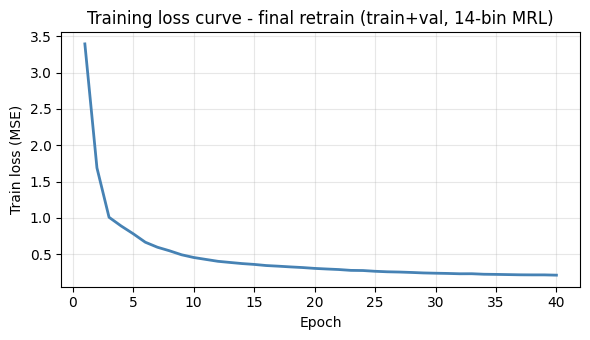


Test PCC (best arch, 14-bin MRL): 0.9379


In [27]:
# Retrain best architecture on full training data (train + val combined).
# Architecture selection is complete; no held-out val set is needed anymore.
# We omit X_v/y_v so train_model runs for the full N_EPOCHS without early stopping.
X_trainval = torch.cat([X_train, X_val])   # merge train + val splits
y_trainval = torch.cat([y_train, y_val])

_, best_model, train_losses = train_model(
    best_config,
    X_trainval, y_trainval,
    n_epochs=N_EPOCHS,
    verbose=True,
    record_loss=True,   # record losses for plotting below
)

# Plot training loss curve directly from this training run
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(range(1, N_EPOCHS + 1), train_losses, color="steelblue", linewidth=2)
ax.set_xlabel("Epoch")
ax.set_ylabel("Train loss (MSE)")
ax.set_title("Training loss curve - final retrain (train+val, 14-bin MRL)")
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(FIG_OUT_DIR / "loss_curve.png", dpi=300, bbox_inches="tight")
plt.show()

# Final evaluation on the completely held-out test set.
test_loader = DataLoader(
    TensorDataset(X_test, y_test.unsqueeze(1)),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)
print(f"\nTest PCC (best arch, 14-bin MRL): {evaluate_pcc(best_model, test_loader):.4f}")

In [28]:
# Save trained model weights and architecture config for reproducibility
torch.save(best_model.state_dict(), DATA_DIR / "best_model_highres.pt")

with open(DATA_DIR / "best_arch_config.json", "w") as f:
    json.dump(best_config, f, indent=2)

print("Model and config saved.")

Model and config saved.


In [29]:
# NOTE: this model is not used downstream. CV folds (trained per resolution
# scheme below) are the models used for evaluation and attribution analysis.
# This run serves as a quick sanity check on the best config before the full CV.

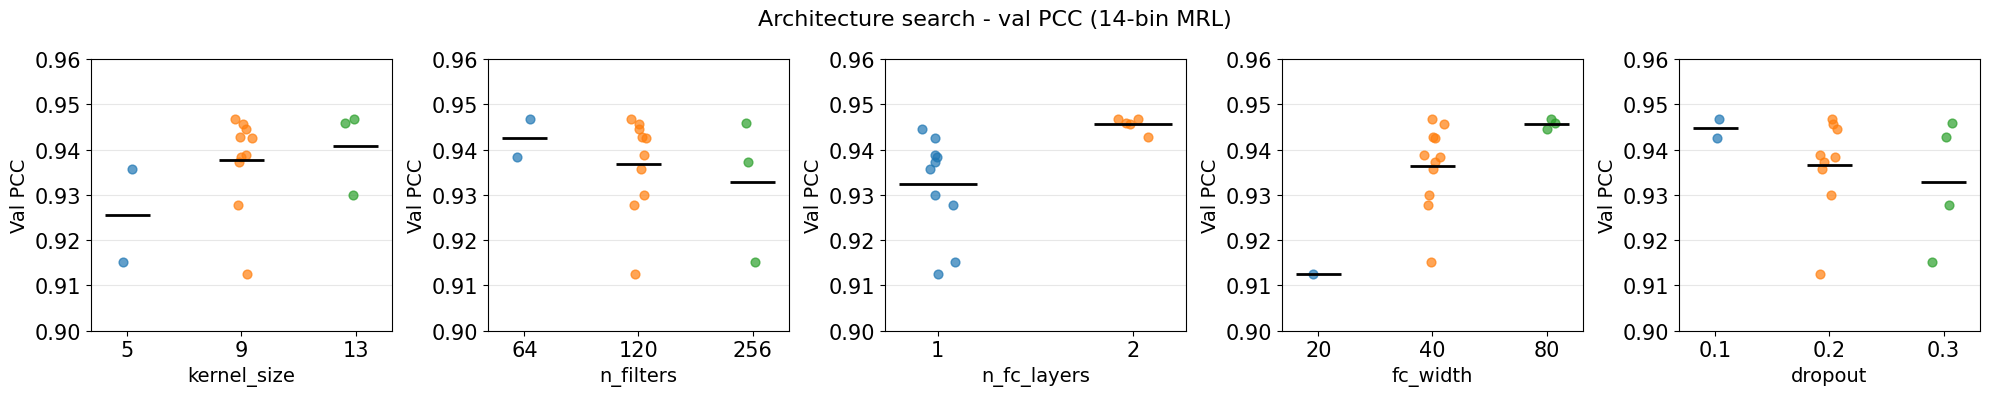

In [30]:
plot_params = ["kernel_size", "n_filters", "n_fc_layers", "fc_width", "dropout"]

fig, axes = plt.subplots(1, len(plot_params), figsize=(4 * len(plot_params), 4))

for ax, param in zip(axes, plot_params):
    unique_vals = sorted(results_df[param].unique())

    for i, v in enumerate(unique_vals):
        pcc_vals = results_df.loc[results_df[param] == v, "val_pcc"].values
        # jitter x position
        jitter = np.random.uniform(-0.1, 0.1, size=len(pcc_vals))
        ax.scatter(np.full(len(pcc_vals), i) + jitter, pcc_vals,
                   alpha=0.7, s=40, zorder=3)
        # add mean line
        ax.hlines(pcc_vals.mean(), i - 0.2, i + 0.2,
                  colors="black", linewidths=2, zorder=4)

    ax.set_xticks(range(len(unique_vals)))
    ax.set_xticklabels([str(v) for v in unique_vals])
    ax.set_xlabel(param)
    ax.set_ylabel("Val PCC")
    ax.set_ylim(0.90, 0.96)
    ax.grid(axis="y", alpha=0.3)

for ax in axes:
    ax.tick_params(labelsize=15)
    ax.set_xlabel(ax.get_xlabel(), fontsize=14)
    ax.set_ylabel(ax.get_ylabel(), fontsize=14)
    ax.set_title(ax.get_title(), fontsize=15)

fig.suptitle("Architecture search - val PCC (14-bin MRL)", fontsize=16)
fig.tight_layout()

fig.savefig(FIG_OUT_DIR / "arch_search_results.png",
            dpi=300, bbox_inches="tight")
plt.show()

---
## 8. Cross-Resolution Evaluation <a id='8'></a>

To assess how polysome profiling resolution affects model performance, we train
CNNs using 5-fold cross-validation independently for each of the four resolution
schemes (14, 7, 5, and 3 bins). For each scheme, low-resolution MRL labels are
computed by merging adjacent bins as described in section 4 and used as training
targets. Evaluation is always performed against the high-resolution 14-bin MRL
on the held-out test set (56,000 sequences), providing a common ground truth for
direct comparison across schemes.

The cross-validation pool consists of the combined train+val set (224,000
sequences), split into 5 folds. For each fold, the model is trained on 4 folds
using low-resolution labels with early stopping, and evaluated on the held-out
fold (low-res val PCC) and on the test set (high-res test PCC). The fixed best
architecture from section 7 is used throughout.

To distinguish model limitations from label limitations, we compute a **label
ceiling** for each scheme: the PCC between the low-resolution and
high-resolution MRL on the test set, without any model:

$$
\text{Label ceiling} = \text{PCC}\left(\text{MRL}^{\text{low-res}}_{\text{test}},\ \text{MRL}^{\text{high-res}}_{\text{test}}\right)
$$

This is a property of the bin merging scheme itself, independent of any model.
A ceiling below 1.0 means that even a perfect model could not fully recover
the high-resolution MRL from low-resolution labels. The gap between the ceiling
and the CNN's achieved PCC then indicates whether the bottleneck is model
capacity or label resolution.

In [31]:
# Reload best architecture config
with open(DATA_DIR / "best_arch_config.json") as f:
    BEST_CONFIG = json.load(f)

# Combine train + val splits for final training
trainval_idx_combined = np.concatenate([train_idx, val_idx])
df_trainval = df.iloc[trainval_idx_combined].reset_index(drop=True)

# Input tensors for train+val (used as the CV pool)
X_trainval = torch.cat([X_train, X_val])

# High-res test labels kept as fixed reference for all resolution evaluations
y_test_highres = y_test

In [32]:
def run_cv_for_scheme(scheme_name, scheme, df_tv, X_tv, X_te, y_te_highres,
                      config, n_splits=5, max_retries=3):
    """K-fold CV for one bin-merge scheme. Returns per-fold metrics + trained models.

    Models are trained on low-resolution MRL labels but evaluated against
    high-resolution labels on the test set.

    If a fold collapses (model predicts a constant, PCC undefined), it is retried
    up to max_retries times with different weight initializations before giving up.
    """

    # Compute low-res MRL labels for this scheme (used for training and val PCC)
    y_lowres = torch.tensor(compute_lowres_mrl(df_tv, scheme), dtype=torch.float32)

    # Test loader always uses the same high-res labels (fixed reference target)
    test_loader = DataLoader(
        TensorDataset(X_te, y_te_highres.unsqueeze(1)),
        batch_size=BATCH_SIZE, shuffle=False
    )

    # KFold splits the train+val pool into n_splits folds
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=SEED)

    fold_results, fold_models = [], []
    for fold, (tr_idx, va_idx) in enumerate(kf.split(X_tv)):
        print(f"  [{scheme_name}] fold {fold+1}/{n_splits} … ", end="", flush=True)

        # Retry loop: reattempt if model collapses to constant output (PCC = nan)
        # Each attempt uses a shifted but deterministic seed to vary initialization
        for attempt in range(max_retries):
            torch.manual_seed(SEED + fold * 100 + attempt) # deterministic per fold+attempt

            # Train on low-res labels, validate on low-res labels
            val_pcc, model, _ = train_model(
                config,
                X_tv[tr_idx], y_lowres[tr_idx], # fold training set
                X_tv[va_idx], y_lowres[va_idx], # fold validation set
            )

            if not np.isnan(val_pcc):
                break # valid result obtained, exit retry loop

            print(f"\n    ↻ fold {fold+1} collapsed (attempt {attempt+1}/{max_retries}), retrying…",
                  end="", flush=True)

        else:
            # for-else: only runs if loop completed without break (all retries collapsed)
            print(f"\n Fold {fold+1} collapsed after {max_retries} attempts, keeping nan.")

        # Restore global seed so the retry seeding does not affect subsequent folds
        torch.manual_seed(SEED)
        np.random.seed(SEED)

        # Evaluate the same model against high-res labels on the held-out test set
        test_pcc = evaluate_pcc(model, test_loader)

        print(f"val_pcc(low-res)={val_pcc:.4f}  test_pcc(high-res)={test_pcc:.4f}")

        fold_results.append({
            "scheme":           scheme_name,
            "n_bins":           len(scheme),
            "fold":             fold + 1,
            "val_pcc_lowres":   val_pcc,   # PCC on low-res val set (training signal)
            "test_pcc_highres": test_pcc,  # PCC on high-res test set (comparison target)
        })
        fold_models.append(model)  # keep models for attribution analysis later

    return fold_results, fold_models

In [33]:
# Run 5-fold CV for every resolution scheme
all_fold_results = []       # flat list of per-fold dicts across all schemes
all_fold_models  = {}       # dict: scheme_name -> list of 5 trained models

for scheme_name, scheme in MERGE_SCHEMES.items():
    print(f"\n{'='*50}\n  {scheme_name}  ({len(scheme)} bins)\n{'='*50}")
    fold_results, fold_models = run_cv_for_scheme(
        scheme_name, scheme,
        df_trainval, X_trainval, X_test, y_test_highres, BEST_CONFIG,
    )
    all_fold_results.extend(fold_results)           # accumulate fold metrics
    all_fold_models[scheme_name] = fold_models      # store models for attribution later

    # Save each fold's weights to disk for reproducibility
    scheme_dir = DATA_DIR / f"models_{scheme_name}"
    scheme_dir.mkdir(exist_ok=True)
    for i, m in enumerate(fold_models):
        torch.save(m.state_dict(), scheme_dir / f"fold{i+1}.pt")

print("\n All CV runs complete.")

# Aggregate fold-level results into a DataFrame
cv_df = pd.DataFrame(all_fold_results)

# Compute mean ± std test PCC per scheme across folds
summary_df = (
    cv_df.dropna(subset=["test_pcc_highres"])          # exclude any collapsed folds
    .groupby(["scheme", "n_bins"])["test_pcc_highres"]
    .agg(mean_pcc="mean", std_pcc="std", n_folds="count")
    .reset_index()
    .sort_values("n_bins", ascending=False)
)

# Save results to disk
cv_df.to_csv(DATA_DIR / "cv_fold_results.csv", index=False)
summary_df.to_csv(DATA_DIR / "cv_summary.csv",  index=False)
print(summary_df.to_string(index=False))

# Label ceiling: PCC(low-res MRL, high-res MRL) on the test set; no model involved.
# Measures only the information lost by bin merging itself.
# A perfect model trained on low-res labels could not exceed this value.
# Gap = ceiling - CNN PCC tells us whether the bottleneck is the model or the resolution.
label_ceiling = {}
for scheme_name, scheme in MERGE_SCHEMES.items():
    pcc = float(pearsonr(compute_lowres_mrl(df_test, scheme), y_test_highres.numpy())[0])
    label_ceiling[scheme_name] = pcc # upper bound imposed by bin merging, not the model
    print(f"  {scheme_name:<10}  label ceiling = {pcc:.4f}")

# Best-fold predictions for scatter plots (Panel C)
# For each scheme, reload the fold with the highest test PCC
best_fold_preds = {}
test_loader_x   = DataLoader(TensorDataset(X_test), batch_size=BATCH_SIZE, shuffle=False) # inputs only, no labels

for scheme_name in SCHEME_ORDER:
    scheme_rows = cv_df[cv_df["scheme"] == scheme_name]
    best_fold   = int(scheme_rows.loc[scheme_rows["test_pcc_highres"].idxmax(), "fold"]) # fold index with highest PCC
    model = CNNModel(**BEST_CONFIG).to(device)
    model.load_state_dict(torch.load(
        DATA_DIR / f"models_{scheme_name}" / f"fold{best_fold}.pt", map_location=device
    ))
    model.eval()
    preds = []
    with torch.no_grad():
        for (xb,) in test_loader_x:
            preds.append(model(xb.to(device)).cpu().squeeze())
    best_fold_preds[scheme_name] = torch.cat(preds).numpy() # shape: (n_test,)

y_true = y_test_highres.numpy() # ground truth high-res MRL for all test sequences


  14_bins  (14 bins)
  [14_bins] fold 1/5 … val_pcc(low-res)=0.9437  test_pcc(high-res)=0.9437
  [14_bins] fold 2/5 … val_pcc(low-res)=0.9453  test_pcc(high-res)=0.9451
  [14_bins] fold 3/5 … val_pcc(low-res)=0.9465  test_pcc(high-res)=0.9472
  [14_bins] fold 4/5 … val_pcc(low-res)=0.9469  test_pcc(high-res)=0.9472
  [14_bins] fold 5/5 … val_pcc(low-res)=0.9473  test_pcc(high-res)=0.9468

  7_bins  (7 bins)
  [7_bins] fold 1/5 … val_pcc(low-res)=0.9441  test_pcc(high-res)=0.9434
  [7_bins] fold 2/5 … val_pcc(low-res)=0.9468  test_pcc(high-res)=0.9462
  [7_bins] fold 3/5 … val_pcc(low-res)=0.9453  test_pcc(high-res)=0.9454
  [7_bins] fold 4/5 … val_pcc(low-res)=0.9472  test_pcc(high-res)=0.9474
  [7_bins] fold 5/5 … val_pcc(low-res)=0.9468  test_pcc(high-res)=0.9458

  5_bins  (5 bins)
  [5_bins] fold 1/5 … val_pcc(low-res)=0.9436  test_pcc(high-res)=0.9441
  [5_bins] fold 2/5 … val_pcc(low-res)=0.9464  test_pcc(high-res)=0.9458
  [5_bins] fold 3/5 … val_pcc(low-res)=0.9463  test_pcc(h

In [35]:
# CV results summary:
# - 14/7/5/3-bin models all reach mean test PCC ~0.945, with ΔPCC < 0.001 across schemes.
# - 2-bin drops to PCC = 0.931, consistent with its lower label ceiling (0.981).
# - val_pcc(low-res) ≈ test_pcc(high-res) for 14 -> 3 bins, confirming low-res labels
#   are sufficient training signal down to 3 bins. Gap widens at 2 bins.

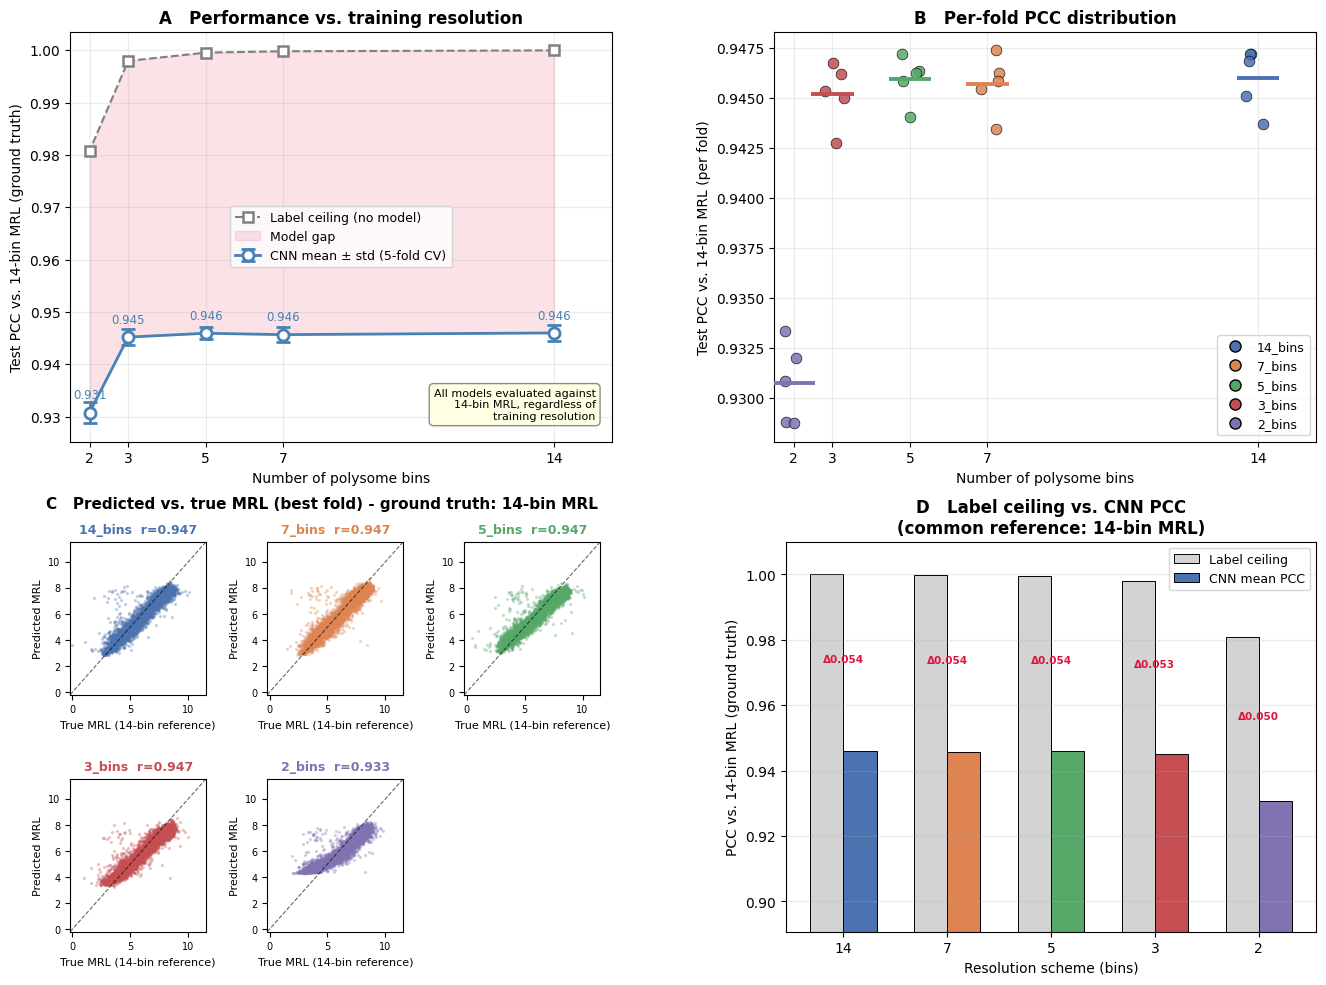

Evaluation figure saved.


In [40]:
# Evaluation figure

# Align all arrays to the same scheme order
summ      = summary_df.set_index("scheme").loc[SCHEME_ORDER]
means     = summ["mean_pcc"].values          # CNN mean test PCC per scheme
stds      = summ["std_pcc"].values           # CNN std test PCC per scheme
ceil_vals = [label_ceiling[s] for s in SCHEME_ORDER]  # label ceiling per scheme
rng       = np.random.default_rng(SEED)      # deterministic jitter/subsampling for plots

# Figure layout: 2 rows, panels A/B on top, C and D on bottom
fig = plt.figure(figsize=(14, 10))
gs_top = fig.add_gridspec(1, 2, top=0.97, bottom=0.56, left=0.08, right=0.97, wspace=0.30)
gs_bot = fig.add_gridspec(1, 2, top=0.46, bottom=0.07, left=0.08, right=0.97, wspace=0.35)
gs_C = gs_bot[0].subgridspec(2, 3, wspace=0.45, hspace=0.55) # 2x3 scatter grid

ax_A   = fig.add_subplot(gs_top[0])                       # A: mean ± std + ceiling
ax_B   = fig.add_subplot(gs_top[1])                       # B: fold-level distribution
axes_C = []
for idx in range(len(SCHEME_ORDER)):  # 5
    axes_C.append(fig.add_subplot(gs_C[idx // 3, idx % 3]))  # C:
ax_D   = fig.add_subplot(gs_bot[1])                       # D: ceiling vs model bars

# Panel A - mean CNN PCC vs resolution, with label ceiling and model gap shaded
ax_A.plot(
    N_BINS_ORDER, ceil_vals, "s--", color="grey", linewidth=1.5,
    markersize=7, markerfacecolor="white", markeredgewidth=1.8,
    label="Label ceiling (no model)"
)
ax_A.errorbar(
    N_BINS_ORDER, means, yerr=stds, fmt="o-", color="steelblue",
    capsize=5, linewidth=2, markersize=8, markerfacecolor="white",
    markeredgewidth=2, label="CNN mean ± std (5-fold CV)"
)
ax_A.fill_between(
    N_BINS_ORDER, means, ceil_vals, alpha=0.12,
    color="crimson", label="Model gap" # gap = ceiling - CNN PCC
)
for nb, m in zip(N_BINS_ORDER, means):
    ax_A.annotate(
        f"{m:.3f}", xy=(nb, m), xytext=(0, 10),
        textcoords="offset points", ha="center", fontsize=8.5, color="steelblue"
    )
ax_A.set_xlabel("Number of polysome bins")
ax_A.set_ylabel("Test PCC vs. 14-bin MRL (ground truth)")
ax_A.set_title("A   Performance vs. training resolution", fontweight="bold")
ax_A.text(
    0.97, 0.05,
    "All models evaluated against\n14-bin MRL, regardless of\ntraining resolution",
    transform=ax_A.transAxes, fontsize=8, va="bottom", ha="right",
    bbox=dict(boxstyle="round,pad=0.4", facecolor="lightyellow", edgecolor="grey", alpha=0.9),
)
ax_A.set_xticks(N_BINS_ORDER)
ax_A.set_xlim(1.5, 15.5)
ax_A.legend(fontsize=9)
ax_A.grid(True, alpha=0.25)

# Panel B - individual fold PCCs per scheme (jittered scatter + mean line)
for i, scheme in enumerate(SCHEME_ORDER):
    fold_pccs = cv_df.loc[cv_df["scheme"] == scheme, "test_pcc_highres"].values
    nb = N_BINS_ORDER[i]
    jitter = rng.uniform(-0.35, 0.35, size=len(fold_pccs))  # avoid point overlap
    ax_B.scatter(
        np.full(len(fold_pccs), nb) + jitter, fold_pccs,
        color=PALETTE[scheme], s=60, alpha=0.85,
        edgecolors="k", linewidths=0.5, zorder=3
    )
    ax_B.hlines(
        means[i], nb - 0.55, nb + 0.55,
        colors=PALETTE[scheme], linewidths=2.8, zorder=4 # mean line per scheme
    )
ax_B.set_xlabel("Number of polysome bins")
ax_B.set_ylabel("Test PCC vs. 14-bin MRL (per fold)")
ax_B.set_title("B   Per-fold PCC distribution", fontweight="bold")
ax_B.set_xticks(N_BINS_ORDER)
ax_B.set_xlim(1.5, 15.5)
ax_B.legend(
    handles=[
        Line2D([0], [0], marker="o", color="w",
               markerfacecolor=PALETTE[s], markeredgecolor="k",
               markersize=8, label=s)
        for s in SCHEME_ORDER
    ],
    fontsize=9
)
ax_B.grid(True, alpha=0.25)

# Panel C - predicted vs true MRL on the test set (best fold per scheme)
for ax_c, scheme in zip(axes_C, SCHEME_ORDER):
    preds   = best_fold_preds[scheme]                         # model predictions on test set
    idx_plt = rng.choice(len(y_true), size=5000, replace=False)  # subsample for readability
    pcc_val = float(pearsonr(preds, y_true)[0])              # full-set PCC for title

    ax_c.scatter(
        y_true[idx_plt], preds[idx_plt],
        s=2, alpha=0.25, color=PALETTE[scheme], rasterized=True
    )

    # Identity line to show deviation from perfect prediction
    lims = [
        min(y_true.min(), preds.min()) - 0.2,
        max(y_true.max(), preds.max()) + 0.2
    ]
    ax_c.plot(lims, lims, "k--", lw=0.8, alpha=0.6)
    ax_c.set_xlim(lims)
    ax_c.set_ylim(lims)
    ax_c.set_xlabel("True MRL (14-bin reference)", fontsize=8)
    ax_c.set_ylabel("Predicted MRL", fontsize=8)
    ax_c.set_title(f"{scheme}  r={pcc_val:.3f}", fontsize=9,
                   fontweight="bold", color=PALETTE[scheme])
    ax_c.tick_params(labelsize=7)
axes_C[0].annotate(
    "C   Predicted vs. true MRL (best fold) - ground truth: 14-bin MRL",
    xy=(-0.18, 1.22), xycoords="axes fraction",
    fontsize=11, fontweight="bold"
)

# Panel D - label ceiling vs CNN mean PCC side-by-side bars with gap annotated
labels_short = [s.replace("_bins", "") for s in SCHEME_ORDER]
x = np.arange(len(SCHEME_ORDER))
w = 0.32
ax_D.bar(
    x - w/2, ceil_vals, w,
    label="Label ceiling", color="lightgrey",
    edgecolor="k", linewidth=0.7
)
ax_D.bar(
    x + w/2, means, w,
    label="CNN mean PCC",
    color=[PALETTE[s] for s in SCHEME_ORDER],
    edgecolor="k", linewidth=0.7
)
for xi, (ceil, mean) in enumerate(zip(ceil_vals, means)):
    ax_D.annotate(
        f"Δ{ceil-mean:.3f}", xy=(xi, mean + (ceil-mean)/2),
        ha="center", fontsize=7.5, color="crimson", fontweight="bold" # gap label
    )
ax_D.set_xticks(x)
ax_D.set_xticklabels(labels_short)
ax_D.set_xlabel("Resolution scheme (bins)")
ax_D.set_ylabel("PCC vs. 14-bin MRL (ground truth)")
ax_D.set_title("D   Label ceiling vs. CNN PCC\n(common reference: 14-bin MRL)", fontweight="bold")
ax_D.set_ylim(min(means) - 0.04, 1.01)
ax_D.legend(fontsize=9)
ax_D.grid(True, axis="y", alpha=0.25)

fig.savefig(FIG_OUT_DIR / "evaluation_pcc_vs_resolution.png", dpi=300, bbox_inches="tight")
plt.show()
print("Evaluation figure saved.")

In [41]:
# Numerical summary table; complement to Figure panels A and D
print(f"\n{'Scheme':<12} {'Bins':>5} {'Label ceil':>11} {'CNN PCC':>9} {'±std':>6} {'Gap':>7}")
print("-" * 52)

for scheme in SCHEME_ORDER:
    row  = summ.loc[scheme]                 # mean/std across folds
    ceil = label_ceiling[scheme]            # theoretical upper bound (label ceiling)

    print(f"{scheme:<12} {int(row['n_bins']):>5} {ceil:>11.4f} "
          f"{row['mean_pcc']:>9.4f} {row['std_pcc']:>6.4f} "
          f"{ceil-row['mean_pcc']:>7.4f}")  # gap = label ceiling − CNN PCC

# Quantify performance loss relative to full-resolution baseline (14 bins)
baseline = summ.loc["14_bins", "mean_pcc"]

print("CNN performance vs label ceiling by resolution")
print("Label ceiling = PCC between low-res and 14-bin MRL labels (no model)")
print()
print(f"{'Scheme':<12} {'Bins':>5} {'Label ceil':>11} {'CNN PCC':>9} {'±std':>6} {'Gap':>7}")
print("-" * 52)

for scheme in SCHEME_ORDER:
    row  = summ.loc[scheme]
    ceil = label_ceiling[scheme]
    print(f"{scheme:<12} {int(row['n_bins']):>5} {ceil:>11.4f} "
          f"{row['mean_pcc']:>9.4f} {row['std_pcc']:>6.4f} "
          f"{ceil-row['mean_pcc']:>7.4f}")

baseline = summ.loc["14_bins", "mean_pcc"]

print()
print("PCC drop relative to 14-bin baseline:")
for scheme in SCHEME_ORDER[1:]:
    drop = baseline - summ.loc[scheme, "mean_pcc"]
    print(f"  14_bins -> {scheme:<10}  ΔPCC = {drop:.4f}  ({drop/baseline*100:.2f}%)")


Scheme        Bins  Label ceil   CNN PCC   ±std     Gap
----------------------------------------------------
14_bins         14      1.0000    0.9460 0.0016  0.0540
7_bins           7      0.9998    0.9457 0.0014  0.0542
5_bins           5      0.9996    0.9459 0.0012  0.0537
3_bins           3      0.9980    0.9452 0.0015  0.0528
2_bins           2      0.9808    0.9307 0.0020  0.0500
CNN performance vs label ceiling by resolution
Label ceiling = PCC between low-res and 14-bin MRL labels (no model)

Scheme        Bins  Label ceil   CNN PCC   ±std     Gap
----------------------------------------------------
14_bins         14      1.0000    0.9460 0.0016  0.0540
7_bins           7      0.9998    0.9457 0.0014  0.0542
5_bins           5      0.9996    0.9459 0.0012  0.0537
3_bins           3      0.9980    0.9452 0.0015  0.0528
2_bins           2      0.9808    0.9307 0.0020  0.0500

PCC drop relative to 14-bin baseline:
  14_bins -> 7_bins      ΔPCC = 0.0003  (0.03%)
  14_bins -> 5_bi

---
## 9. Attribution Analysis via Integrated Gradients <a id='9'></a>

To assess whether models trained at different label resolutions learn different
sequence features, we apply **Integrated Gradients (IG)** to the trained CNNs.

IG is an input attribution method that assigns an importance score to each input
feature by integrating the model's gradients along a straight path from a
reference (baseline) input to the actual input. It measures how much each input feature contributed to the difference in model output between the baseline and the actual sequence. We use an all-zeros tensor as baseline, representing a sequence with no nucleotide signal.

Attributions are computed over the one-hot input tensor (shape: $N \times 4
\times 50$), giving one attribution value per nucleotide per position. These
are collapsed to a positional importance profile by taking the L2 norm across
the 4 nucleotide channels and averaging across sequences, yielding a single
importance value per position (0–49).

Attributions are computed for two subsets of the test set:

- **5,000 randomly selected sequences**: global positional importance profile
- **500 top-decile MRL sequences** (MRL ≥ 90th percentile): importance profile
  for highly translated sequences specifically

For each resolution scheme, attributions are computed from the best-performing
fold (highest test PCC). Profiles are then compared across resolutions using
Pearson correlation to quantify whether models trained on different resolutions
learn similar or divergent positional features.

In [42]:
def compute_ig_attributions(model, X_subset, n_steps=50, batch_size=64):
    """
    Compute signed Integrated Gradients (IG) attributions.
    Returns array of shape (N, 4, 50) matching one-hot input channels.
    """
    model.eval()  # ensure deterministic behavior (no dropout)
    ig = IntegratedGradients(model)
    # Zero baseline corresponds to "no nucleotide" at all positions
    baseline = torch.zeros(1, 4, 50, device=device)

    all_attrs = []
    for start in range(0, len(X_subset), batch_size):
        xb = X_subset[start : start + batch_size].to(device)

        # IG integrates gradients along straight path from baseline -> input
        attr = ig.attribute(
            xb,
            baselines=baseline.expand(len(xb), -1, -1),  # same baseline for each sequence
            n_steps=n_steps,                               # integration steps (more = more accurate)
            return_convergence_delta=False,
        )

        all_attrs.append(attr.cpu().detach().numpy())

    return np.concatenate(all_attrs, axis=0) # shape: (N, 4, 50)

In [43]:
def attribution_to_profile(attrs):
    """
    Collapse (N, 4, 50) attribution tensor to a (50,) positional importance profile.
    L2 norm across the 4 nucleotide channels, then mean across sequences.
    """
    return np.linalg.norm(attrs, axis=1).mean(axis=0) # (N,50) -> (50,)

# Random subset of test sequences for global attribution analysis
rng_attr = np.random.default_rng(SEED + 1)                          # separate seed from main rng
attr_idx = rng_attr.choice(len(X_test), size=5000, replace=False)   # 5k random test sequences
X_attr   = X_test[attr_idx]

# Top-decile sequences by true high-res MRL (for motif-specific analysis)
top_thresh  = np.percentile(y_true, 90)                             # MRL threshold for top 10%
top_idx_all = np.where(y_true >= top_thresh)[0]                     # indices of top-decile sequences
top_idx     = rng_attr.choice(top_idx_all,
                              size=min(500, len(top_idx_all)),
                              replace=False)                         # subsample up to 500
X_top = X_test[top_idx]

print(f"Attribution subset : {len(X_attr)} seqs")
print(f"Top-decile subset  : {len(X_top)} seqs  (MRL ≥ {top_thresh:.2f})")

Attribution subset : 5000 seqs
Top-decile subset  : 500 seqs  (MRL ≥ 8.30)


In [44]:
# Compute IG attributions for the best fold of each resolution scheme.
# Using the best fold (highest test PCC) ensures we attribute from the
# strongest model available for each resolution.
ig_attrs     = {}  # global subset attributions per scheme
ig_attrs_top = {}  # top-decile subset attributions per scheme

for scheme_name in SCHEME_ORDER:
    print(f"Computing IG for {scheme_name} … ", end="", flush=True)

    # Select fold with highest test PCC for this scheme
    scheme_rows = cv_df[cv_df["scheme"] == scheme_name]
    best_fold = int(
        scheme_rows.loc[
            scheme_rows["test_pcc_highres"].idxmax(),
            "fold"
        ]
    )

    # Reload corresponding trained model
    model = CNNModel(**BEST_CONFIG).to(device)
    model.load_state_dict(
        torch.load(
            DATA_DIR / f"models_{scheme_name}" / f"fold{best_fold}.pt",
            map_location=device
        )
    )

    # Global attribution subset
    ig_attrs[scheme_name] = compute_ig_attributions(model, X_attr) # shape: (5000, 4, 50)

    # Top-decile attribution subset
    ig_attrs_top[scheme_name] = compute_ig_attributions(model, X_top) # shape: (500,  4, 50)

    print("done.")

# Save attribution arrays for reproducibility (can be reloaded without rerunning IG)
np.savez(DATA_DIR / "ig_attributions.npz",     **ig_attrs)
np.savez(DATA_DIR / "ig_attributions_top.npz", **ig_attrs_top)
print("Attributions saved.")

Computing IG for 14_bins … done.
Computing IG for 7_bins … done.
Computing IG for 5_bins … done.
Computing IG for 3_bins … done.
Computing IG for 2_bins … done.
Attributions saved.


In [45]:
# Prepare attribution summaries for visualization and comparison
positions  = np.arange(50)          # sequence positions (0-49)
nuc_labels = ['A', 'C', 'G', 'T']   # channel order matching one-hot encoding

# Collapse each attribution tensor to a (50,) positional importance profile
profiles = {
    s: attribution_to_profile(ig_attrs[s])
    for s in SCHEME_ORDER
}

# Same for top-decile sequences
profiles_top = {
    s: attribution_to_profile(ig_attrs_top[s])
    for s in SCHEME_ORDER
}

# Pairwise Pearson correlation between positional profiles across resolutions.
# Low correlation = models learned different positional features.
n_schemes   = len(SCHEME_ORDER)
corr_matrix = np.zeros((n_schemes, n_schemes))

for i, s1 in enumerate(SCHEME_ORDER):
    for j, s2 in enumerate(SCHEME_ORDER):
        corr_matrix[i, j] = float(
            pearsonr(profiles[s1], profiles[s2])[0]
        )

print("Cross-resolution attribution profile correlation (Pearson r)")
print("Measures similarity of positional importance profiles between resolution schemes.")
print("Low off-diagonal values indicate models learned different sequence features.")
print()
print(
    pd.DataFrame(
        corr_matrix,
        index=[s.replace("_bins", "") for s in SCHEME_ORDER],
        columns=[s.replace("_bins", "") for s in SCHEME_ORDER],
    ).round(4)
)

Cross-resolution attribution profile correlation (Pearson r)
Measures similarity of positional importance profiles between resolution schemes.
Low off-diagonal values indicate models learned different sequence features.

        14       7       5       3       2
14  1.0000  0.7084  0.8503  0.5869  0.5058
7   0.7084  1.0000  0.8038  0.5759  0.4332
5   0.8503  0.8038  1.0000  0.6511  0.5915
3   0.5869  0.5759  0.6511  1.0000  0.8916
2   0.5058  0.4332  0.5915  0.8916  1.0000


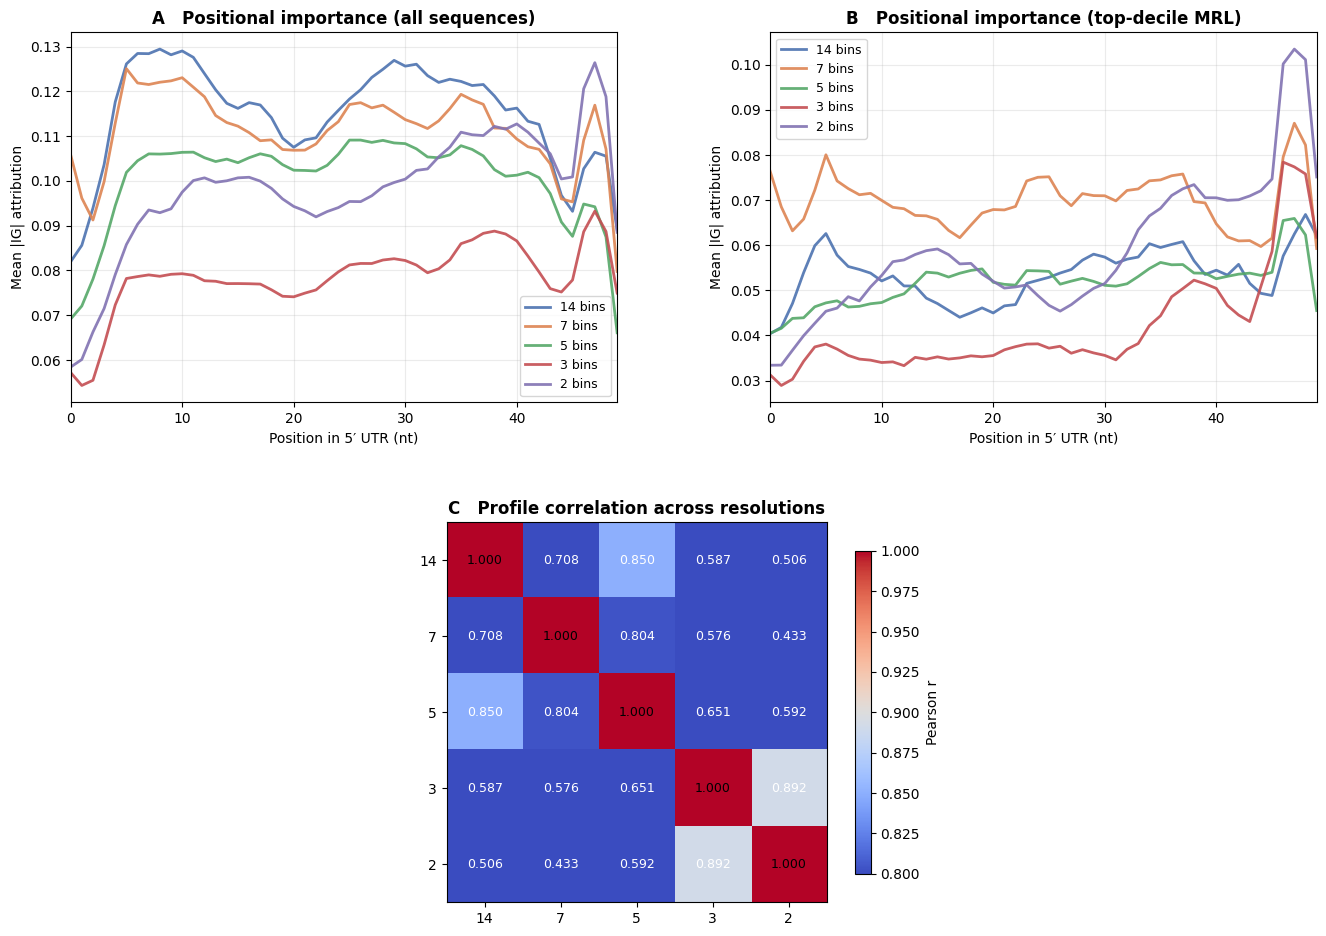

Attribution figure saved.


In [46]:
# Attribution figure (A, B, C)
# A: positional importance profile (all sequences)
# B: positional importance profile (top-decile MRL)
# C: correlation of profiles across resolution schemes

fig = plt.figure(figsize=(14, 10))
gs_top = fig.add_gridspec(1, 2, top=0.95, bottom=0.58, left=0.08, right=0.97, wspace=0.28)
gs_bot = fig.add_gridspec(1, 1, top=0.46, bottom=0.08, left=0.30, right=0.70)
ax_A = fig.add_subplot(gs_top[0])
ax_B = fig.add_subplot(gs_top[1])
ax_C = fig.add_subplot(gs_bot[0])

# Panels A & B - smoothed positional importance profiles per resolution
for ax, prof_dict, title in [
    (ax_A, profiles,     "A   Positional importance (all sequences)"),
    (ax_B, profiles_top, "B   Positional importance (top-decile MRL)"),
]:
    for scheme in SCHEME_ORDER:
        ax.plot(
            positions,
            uniform_filter1d(prof_dict[scheme], size=3), # light smoothing for readability
            color=PALETTE[scheme],
            linewidth=2,
            label=scheme.replace("_bins", " bins"),
            alpha=0.9,
        )
    ax.set_xlabel("Position in 5′ UTR (nt)")
    ax.set_ylabel("Mean |IG| attribution")
    ax.set_title(title, fontweight="bold")
    ax.set_xlim(0, 49)
    ax.grid(True, alpha=0.25)
    ax.legend(fontsize=9)

# Panel C - correlation heatmap of positional profiles between resolutions
# Low off-diagonal values indicate different features learned at different resolutions
tick_labels = [s.replace("_bins", "") for s in SCHEME_ORDER]
im_c = ax_C.imshow(corr_matrix, cmap="coolwarm", vmin=0.8, vmax=1.0, interpolation="nearest")

ax_C.set_xticks(range(n_schemes))
ax_C.set_xticklabels(tick_labels, fontsize=10)
ax_C.set_yticks(range(n_schemes))
ax_C.set_yticklabels(tick_labels, fontsize=10)
ax_C.set_title("C   Profile correlation across resolutions", fontweight="bold")
fig.colorbar(im_c, ax=ax_C, shrink=0.85, label="Pearson r")

# Annotate each cell with its correlation value
for i in range(n_schemes):
    for j in range(n_schemes):
        ax_C.text(
            j, i, f"{corr_matrix[i, j]:.3f}",
            ha="center", va="center", fontsize=9,
            color="white" if corr_matrix[i, j] < 0.92 else "black", # contrast for readability
        )

fig.savefig(FIG_OUT_DIR / "attribution_comparison_ABC.png", dpi=300, bbox_inches="tight")
plt.show()
print("Attribution figure saved.")

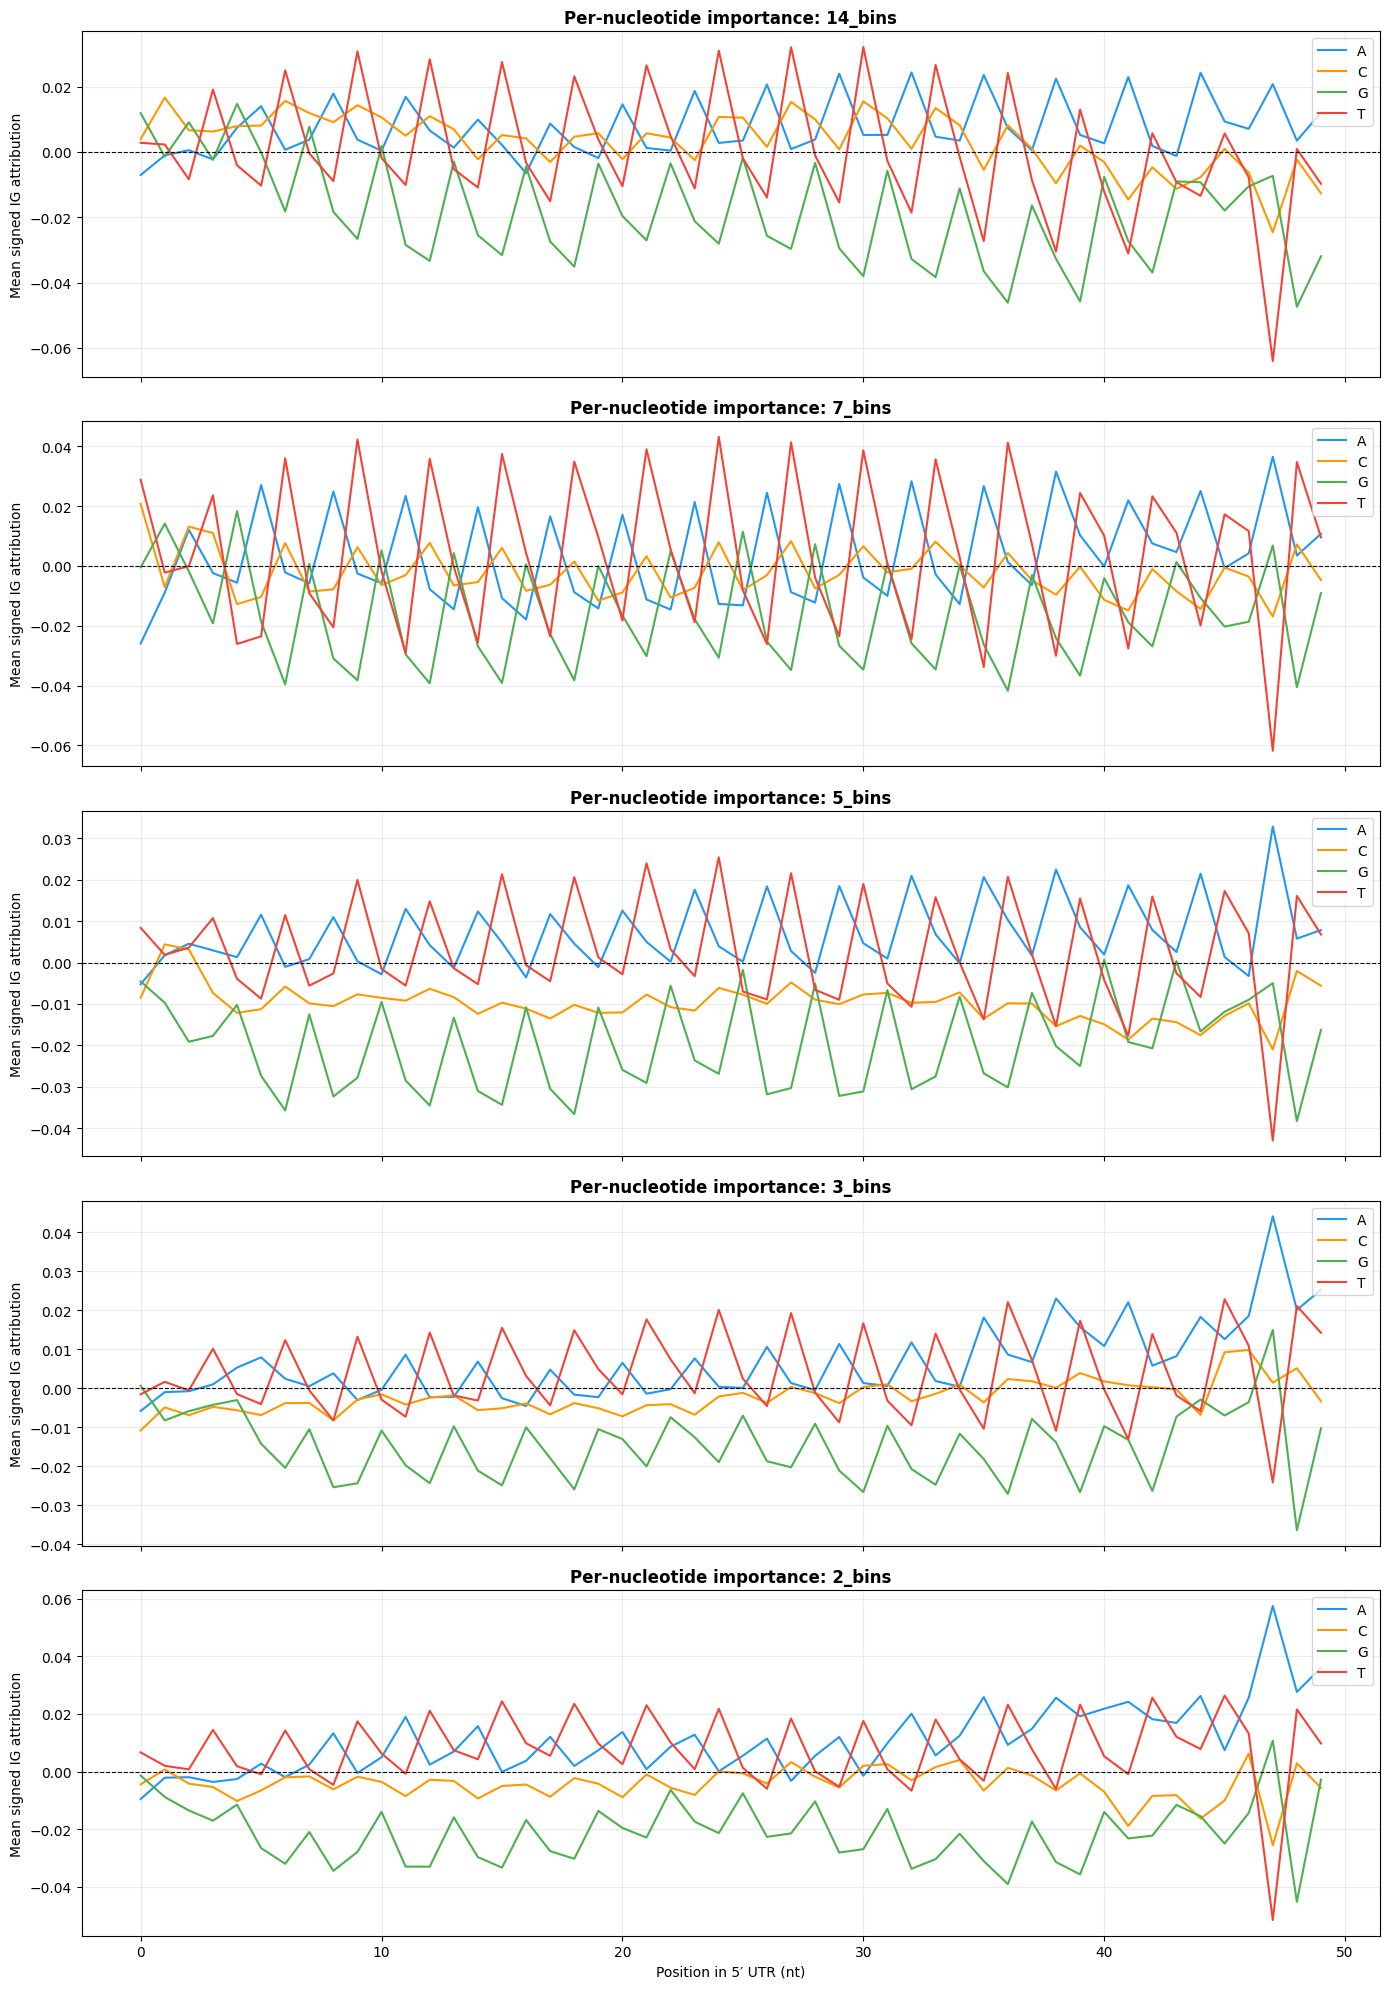

In [47]:
# Reload if needed
ig_attrs = dict(np.load(DATA_DIR / "ig_attributions.npz"))

# Per-nucleotide importance - all schemes stacked
fig, axes = plt.subplots(len(SCHEME_ORDER), 1, figsize=(14, 4 * len(SCHEME_ORDER)), sharex=True)
colors = ['#2196F3', '#FF9800', '#4CAF50', '#F44336']  # A C G T

for ax, scheme in zip(axes, SCHEME_ORDER):
    mean_attr = ig_attrs[scheme].mean(axis=0)  # (4, 50)
    for i, (nuc, col) in enumerate(zip(nuc_labels, colors)):
        ax.plot(positions, mean_attr[i], label=nuc, color=col, linewidth=1.5)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_ylabel("Mean signed IG attribution")
    ax.set_title(f"Per-nucleotide importance: {scheme}", fontweight="bold")
    ax.legend(loc="upper right")
    ax.grid(True, alpha=0.25)

axes[-1].set_xlabel("Position in 5′ UTR (nt)")
fig.tight_layout()
fig.savefig(FIG_OUT_DIR / "per_nucleotide_importance_all_schemes.png", dpi=300, bbox_inches="tight")
plt.show()

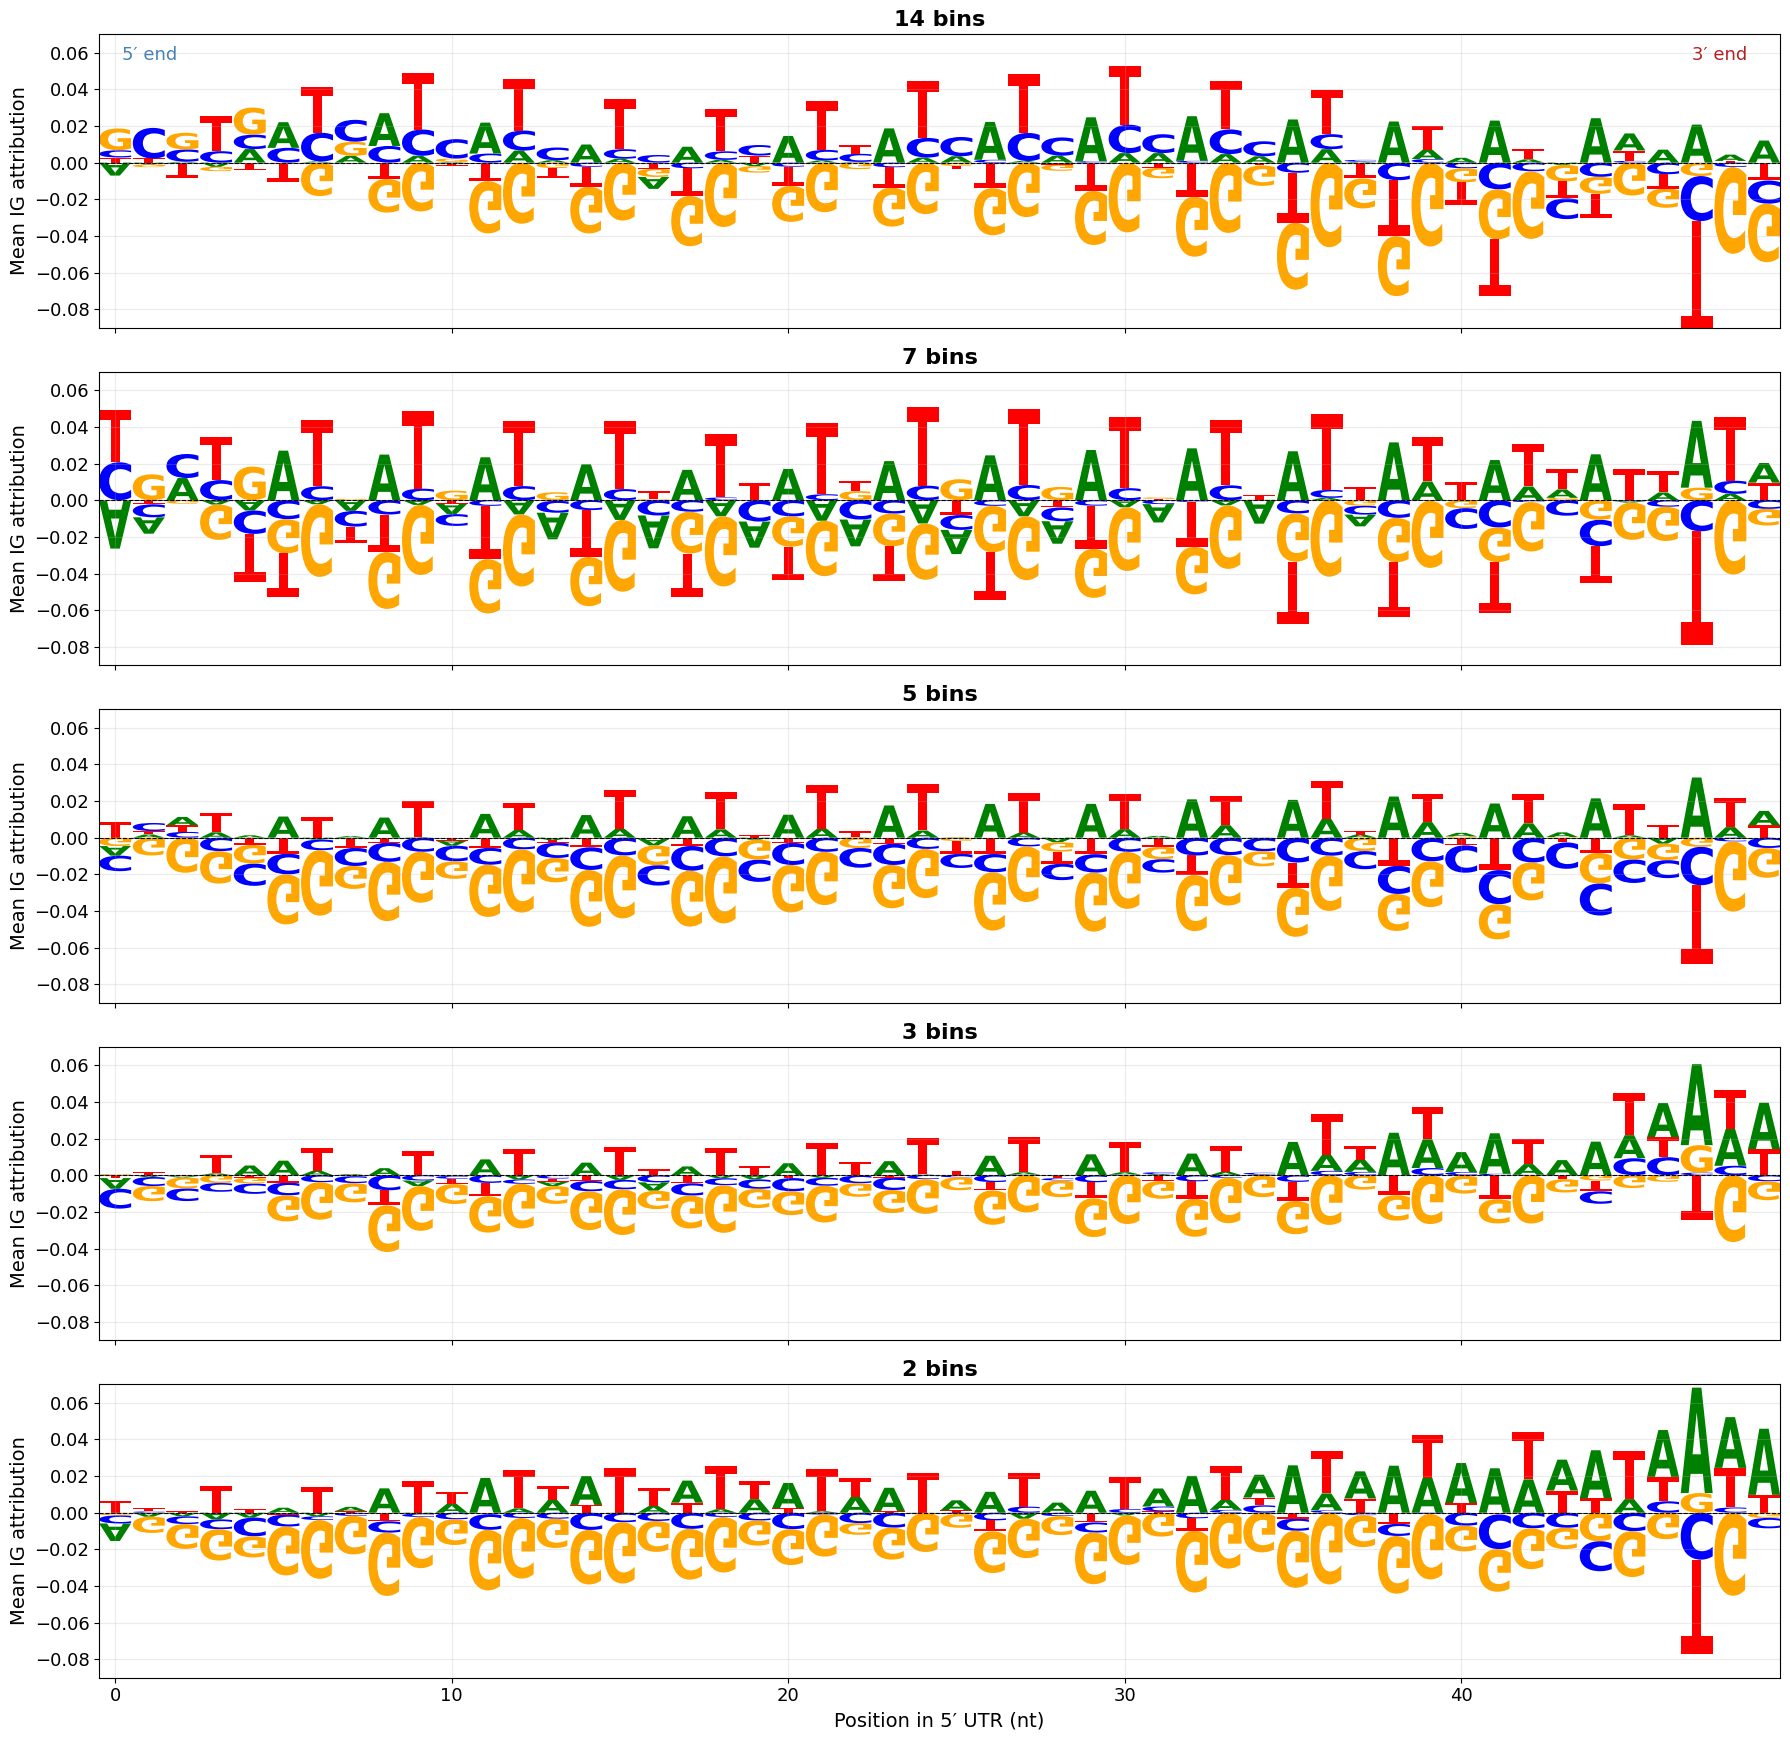

In [55]:
!pip -q install logomaker

import logomaker

FONT = 14
y_min, y_max = -0.09, 0.07

fig, axes = plt.subplots(len(SCHEME_ORDER), 1,
                         figsize=(18, 3.5 * len(SCHEME_ORDER)), sharex=True)

for i, (ax, scheme) in enumerate(zip(axes, SCHEME_ORDER)):
    mean_attr = ig_attrs[scheme].mean(axis=0).T  # (50, 4)
    logo_df = pd.DataFrame(mean_attr, columns=nuc_labels)
    logomaker.Logo(logo_df, ax=ax, color_scheme='classic')
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')

    # 5' end marker
    ax.axvline(-0.5, color='steelblue', linewidth=2.0, linestyle=':', alpha=0.8)

    # Landmark labels on first panel only
    if i == 0:
        ax.text(0.2,  y_max * 0.80, "5′ end",
                color='steelblue', fontsize=FONT - 1)
        ax.text(48.50, y_max * 0.80, "3′ end",
                color='firebrick', fontsize=FONT - 1, ha='right')

    ax.set_ylabel("Mean IG attribution", fontsize=FONT)
    ax.set_title(scheme.replace("_", " "), fontsize=FONT + 2, fontweight="bold")
    ax.set_ylim(y_min, y_max)
    ax.tick_params(labelsize=FONT - 1)
    ax.grid(True, alpha=0.25)

axes[-1].set_xlabel("Position in 5′ UTR (nt)", fontsize=FONT)
fig.tight_layout()
fig.savefig(FIG_OUT_DIR / "attribution_logo_all_schemes.png", dpi=300, bbox_inches="tight")
plt.show()